# InMemory Store

In [1]:
from platform import system

from key_value.aio.stores.base import BaseStore
from langgraph.store.memory import InMemoryStore

In [2]:
# store
store = InMemoryStore()

In [3]:
# create namespace
namespace = ("user", "u1")
namespace2 = ("user", "u2")

## Creating Memory

In [4]:
# adding memories
store.put(namespace, "1", "hi")
store.put(namespace, "2", "hi i am jayesh")
store.put(namespace2, "1", "hi nice to meet you")
store.put(namespace2, "2", "hi i am rahul")

## Retrieve Memory

In [5]:
store.get(namespace, "2")

Item(namespace=['user', 'u1'], key='2', value='hi i am jayesh', created_at='2026-09-05T12:09:05.652867+00:00', updated_at='2026-09-05T12:09:05.652867+00:00')

## Retrieve all memory

In [6]:
store.search(namespace)

[Item(namespace=['user', 'u1'], key='1', value='hi', created_at='2026-09-05T12:09:05.652845+00:00', updated_at='2026-09-05T12:09:05.652845+00:00', score=None),
 Item(namespace=['user', 'u1'], key='2', value='hi i am jayesh', created_at='2026-09-05T12:09:05.652867+00:00', updated_at='2026-09-05T12:09:05.652867+00:00', score=None)]

# semantic search inmemory

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

In [8]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-large-en-v1.5"
)

/Users/jayeshp/PycharmProjects/Langgraph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
store = InMemoryStore(index={"embed": embedding_model})
namespace = ("user", "u1")

In [ ]:
store.put(namespace, "key1", "The sun rises over the quiet mountains.")
store.put(namespace, "key2", "She enjoys reading books on rainy evenings.")
store.put(namespace, "key3", "The team completed the project ahead of schedule.")
store.put(namespace, "key4", "A gentle breeze moved through the green trees.")
store.put(namespace, "key5", "He learned a new programming concept today.")
store.put(namespace, "key6", "The restaurant served a delicious homemade meal.")
store.put(namespace, "key7", "Children played happily in the nearby park.")
store.put(namespace, "key8", "The train arrived at the station on time.")
store.put(namespace, "key9", "Technology continues to change the way we work.")
store.put(namespace, "key10", "She started her morning with a cup of coffee.")

In [ ]:
store.search(namespace, query='what is the train', limit=2)

# Chatbot with existing memory

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["LANGCHAIN_PROJECT"] = "longTermMemory"

from langgraph.store.memory import InMemoryStore, BaseStore
from langchain_core.runnables import RunnableSequence, RunnableConfig

In [ ]:
# memory store
store = InMemoryStore()

namespace = ("user", "u1")

store.put(namespace, "key1", "The user name is Jayesh.")
store.put(namespace, "key2", "He likes to play cricket.")
store.put(namespace, "key3", "He is a mechanical engineer.")
store.put(namespace, "key4", "He is expert in python programming.")

In [ ]:
# llm
llm = HuggingFacePipeline.from_model_id(
        model_id="Qwen/Qwen2.5-3B-Instruct",
        task="text-generation",
        pipeline_kwargs={
            "temperature": 0.2,
            "return_full_text":False,
        },
    )
chat_model = ChatHuggingFace(llm=llm)

In [ ]:
# state
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


# chat node
def chat_node(state: ChatState, config: RunnableConfig, store: BaseStore):
    # memory
    user_id = config["configurable"]["user_id"]
    user_details = store.search(("user", user_id))
    # prompt
    system_prompt = """
        You are a helpful assistant with memory capability.
        If user specific memory is available, use it to personalize your response.

        The user's memory (which can be empty) is provided as : {user_details}
    """
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        MessagesPlaceholder("prev_conv")
    ])

    chain = RunnableSequence(prompt_template, chat_model)
    response = chain.invoke(input= {"user_details" : user_details,
                                    "prev_conv" : state["messages"]})
    return {"messages": [response]}


# graph
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(store=store)


# invoke
initial_state = {"messages": [HumanMessage("Hi can you write code to add 2 int")]}
config = {"configurable": {"user_id": "u1"}}
response_state = chatbot.invoke(input=initial_state, config=config)


In [ ]:
response_state

# Chatbot creating new memory

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
load_dotenv()
import os
api_key = os.getenv("DEEPSEEK_API_KEY")
import uuid

from langgraph.store.memory import InMemoryStore, BaseStore
from langchain_core.runnables import RunnableSequence, RunnableConfig

In [2]:
# model
ai_model = ChatDeepSeek(api_key=api_key, model="deepseek-v4-flash")
# store
store = InMemoryStore()


# state
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


# extractor format
class ExtractInfo(BaseModel):
    to_add: bool = Field(
        description="Whether the user's message contains new information worth storing as long-term memory."
    )
    summary: list[str] = Field(
        default_factory=list,
        description="New, concise, self-contained memories to store."
    )
parser = PydanticOutputParser(pydantic_object=ExtractInfo)


# memory_node
def memory_node(state: ChatState, config: RunnableConfig, store: BaseStore):
    # load prev memory
    user_id = config["configurable"]["user_id"]
    name_space = ("user", user_id)
    prev_memory = store.search(name_space)

    system_prompt = """
        You are a memory extraction assistant.

        Analyze the user's latest message and identify important information
        that would be useful for personalizing future responses.

        Store information such as:
        - User preferences
        - Learning goals
        - Long-term interests
        - Ongoing projects
        - Coding or response preferences
        - Recurring requirements
        - Useful information about how the user prefers to work

        Only extract information that is:
        - Relevant to future conversations
        - Likely to remain useful
        - Explicitly stated or clearly implied
        - Helpful for personalizing future responses

        Do NOT store:
        - Temporary or one-time information
        - Secrets such as passwords, API keys, or tokens
        - Financial account details
        - Guesses or assumptions
        - Information that is not useful for future personalization

        IMPORTANT:
        You are also given the user's previously stored memories.

        Previous memories:
        {prev_memory}

        Before creating a new memory, compare the user's latest message
        against the previous memories.

        If the information from the latest message is already present
        in the previous memories, do NOT add it again.

        If ALL useful information from the latest message already exists
        in previous memories:
        - Set `to_add` to false
        - Return an empty `summary` list

        If the latest message contains NEW useful information:
        - Set `to_add` to true
        - Add ONLY the new information to `summary`
        - Do not repeat information already present in previous memories

        Each memory should be a short, clear, self-contained statement.

        Return ONLY the output following these format instructions:

        {format_instructions}
    """
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("user", "{user_message}")
    ]).partial(format_instructions=parser.get_format_instructions())

    chain = RunnableSequence(prompt_template, ai_model, parser)
    response = chain.invoke(input={"user_message": state["messages"][-1].content,
                                   "prev_memory": prev_memory})


    if response.to_add:
        store.put(name_space, str(uuid.uuid4()), response.summary)

    return {"summary": response.summary}


# chat node
def chat_node(state: ChatState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    user_details = store.search(("user", user_id))

    system_prompt = """
        You are a helpful assistant with memory capability.
        If user specific memory is available, use it to personalize your response.

        The user's memory (which can be empty) is provided as : {user_details}
    """
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        MessagesPlaceholder("prev_conv")
    ])

    chain = RunnableSequence(prompt_template, ai_model)
    response = chain.invoke(input= {"user_details" : user_details,
                                    "prev_conv" : state["messages"]})

    return {"messages": [response]}


# graph
graph = StateGraph(ChatState)
graph.add_node("memory_node", memory_node)
graph.add_node("chat_node", chat_node)

graph.add_edge(START, "memory_node")
graph.add_edge("memory_node", "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(store=store)



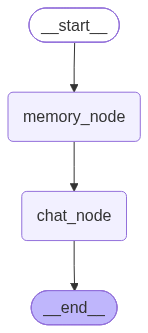

In [3]:
chatbot

In [4]:
# invoke 1
initial_state = {"messages": [HumanMessage("Hi I am jayesh")]}
config = {"configurable": {"user_id": "u1"}}
response_state = chatbot.invoke(input=initial_state, config=config)

In [5]:
for messages in response_state["messages"]:
    print(messages.content)

Hi I am jayesh
Hello Jayesh! It's great to see you again. I remember that your name is Jayesh from our previous interaction.

How can I help you today?


In [6]:
# invoke 2
initial_state = {"messages": [HumanMessage("I code in python")]}
config = {"configurable": {"user_id": "u1"}}
response_state = chatbot.invoke(input=initial_state, config=config)

In [7]:
for messages in response_state["messages"]:
    print(messages.content)

I code in python
Got it, Jayesh! Since you code in Python, how can I help you today? Need any code examples, debugging, or best practices?


In [8]:
# invoke 3
initial_state = {"messages": [HumanMessage("Write code to check is prime")]}
config = {"configurable": {"user_id": "u1"}}
response_state = chatbot.invoke(input=initial_state, config=config)

In [9]:
for messages in response_state["messages"]:
    print(messages.content)

Write code to check is prime
Hey Jayesh! Since you're coding in Python, here's a clean and efficient primality test:

```python
import math

def is_prime(n: int) -> bool:
    """Return True if n is a prime number, False otherwise."""
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    
    limit = int(math.sqrt(n))
    for i in range(3, limit + 1, 2):
        if n % i == 0:
            return False
    return True
```

**How it works:**
- Handles edge cases: negative numbers, 0, and 1 are not prime.
- 2 is prime; even numbers greater than 2 are not.
- Only checks odd divisors up to √n — much faster for large numbers.

**Example usage:**
```python
print(is_prime(17))   # True
print(is_prime(15))   # False
print(is_prime(2))    # True
```

Want me to also include a version that checks many numbers efficiently (like a sieve for ranges)? Just let me know!


In [10]:
store.search(("user", "u1"))

[Item(namespace=['user', 'u1'], key='f0dde3a3-00e4-43ca-8747-751d9c85c217', value=["User's name is Jayesh."], created_at='2026-09-05T12:09:26.960419+00:00', updated_at='2026-09-05T12:09:26.960421+00:00', score=None),
 Item(namespace=['user', 'u1'], key='9e075877-8668-4842-be9b-ec67d9450cdc', value=['User codes in Python.'], created_at='2026-09-05T12:09:41.335636+00:00', updated_at='2026-09-05T12:09:41.335638+00:00', score=None)]

In [11]:
# invoke 4
initial_state = {"messages": [HumanMessage("I am a coder in python")]}
config = {"configurable": {"user_id": "u1"}}
response_state = chatbot.invoke(input=initial_state, config=config)

In [13]:
store.search(("user", "u1"))

[Item(namespace=['user', 'u1'], key='f0dde3a3-00e4-43ca-8747-751d9c85c217', value=["User's name is Jayesh."], created_at='2026-09-05T12:09:26.960419+00:00', updated_at='2026-09-05T12:09:26.960421+00:00', score=None),
 Item(namespace=['user', 'u1'], key='9e075877-8668-4842-be9b-ec67d9450cdc', value=['User codes in Python.'], created_at='2026-09-05T12:09:41.335636+00:00', updated_at='2026-09-05T12:09:41.335638+00:00', score=None)]